In [1]:
# Cell 1: Imports and setup
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import time
from scipy.optimize import linear_sum_assignment

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
# Cell 2: Hyperparameters and data loading
# Hyperparameters
batch_size = 128
latent_dim = 10
num_components = 10  # For the 10 digits
epochs = 100  # Set higher for early stopping
learning_rate = 1e-3
beta = 1.0  # Weight for KL term
gamma = 0.1  # Weight for separation regularizer
patience = 10  # For early stopping

# Data preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

# Load MNIST dataset
train_dataset_full = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset_full = datasets.MNIST('./data', train=False, transform=transform)

# Reduce dataset size for faster execution
train_size_full = len(train_dataset_full)
test_size_full = len(test_dataset_full)

# Define reduced sizes (e.g., 10% of original size)
reduced_train_size = int(0.05 * train_size_full)
reduced_test_size = int(0.05 * test_size_full)

train_dataset, _ = torch.utils.data.random_split(
    train_dataset_full, [reduced_train_size, train_size_full - reduced_train_size]
)
test_dataset, _ = torch.utils.data.random_split(
    test_dataset_full, [reduced_test_size, test_size_full - reduced_test_size]
)

# Split training set for validation
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    train_dataset, [train_size, val_size]
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 133MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 20.9MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 65.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]


In [3]:
# Cell 3: Model initialization and architecture definitions
# Model initialization function
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# GMVAE Model
class GMVAE(nn.Module):
    def __init__(self, input_dim=784, latent_dim=10, num_components=10):
        super(GMVAE, self).__init__()
        self.latent_dim = latent_dim
        self.num_components = num_components

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
        )

        # Latent space parameters
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        # Mixture weights (prior)
        self.pi = nn.Parameter(torch.ones(num_components) / num_components)

        # Mixture components (means and variances)
        self.mu_c = nn.Parameter(torch.randn(num_components, latent_dim))
        self.logvar_c = nn.Parameter(torch.zeros(num_components, latent_dim))

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim),
            nn.Sigmoid()
        )

        # Apply initialization
        self.apply(init_weights)

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        # Encode input
        mu_z, logvar_z = self.encode(x.view(-1, 784))

        # Reparameterization trick
        z = self.reparameterize(mu_z, logvar_z)

        # Decode
        x_recon = self.decode(z)

        return x_recon, mu_z, logvar_z, z

    def compute_loss(self, x, x_recon, mu_z, logvar_z, z):
        # Reconstruction loss
        # Clip input to [0, 1] range
        x_clipped = torch.clamp(x.view(-1, 784), 0, 1)
        recon_loss = F.binary_cross_entropy(x_recon, x_clipped, reduction='sum')

        # KL divergence with mixture prior
        # Expand z for broadcasting: [batch_size, latent_dim] -> [batch_size, num_components, latent_dim]
        z_expanded = z.unsqueeze(1).expand(-1, self.num_components, -1)

        # Compute log probability of z under each mixture component
        log_prob = -0.5 * (
            self.logvar_c.unsqueeze(0) +
            ((z_expanded - self.mu_c.unsqueeze(0)) ** 2) / torch.exp(self.logvar_c.unsqueeze(0)) +
            torch.log(torch.tensor(2 * np.pi))
        ).sum(2)

        # Add log prior
        log_prob = log_prob + torch.log(self.pi.unsqueeze(0))

        # Compute the KL divergence
        log_q_z = -0.5 * (logvar_z + ((z - mu_z) ** 2) / torch.exp(logvar_z) + torch.log(torch.tensor(2 * np.pi))).sum(1)

        # Log-sum-exp for numerical stability
        log_sum_exp = torch.logsumexp(log_prob, dim=1)
        kl_loss = (log_q_z - log_sum_exp).sum()

        # Separation regularizer (novelty component)
        # Encourage cluster centers to be separated
        pair_dists = torch.cdist(self.mu_c, self.mu_c, p=2)
        mask = ~torch.eye(self.num_components, dtype=bool).to(device)
        sep_loss = -torch.mean(1.0 / (pair_dists[mask] + 1e-6))  # Negative because we want to maximize distances

        total_loss = recon_loss + beta * kl_loss + gamma * sep_loss

        return total_loss, recon_loss, kl_loss, sep_loss

    def cluster_assignments(self, z):
        # Compute responsibilities for each data point
        z_expanded = z.unsqueeze(1).expand(-1, self.num_components, -1)

        log_prob = -0.5 * (
            self.logvar_c.unsqueeze(0) +
            ((z_expanded - self.mu_c.unsqueeze(0)) ** 2) / torch.exp(self.logvar_c.unsqueeze(0)) +
            torch.log(torch.tensor(2 * np.pi))
        ).sum(2)

        log_prob = log_prob + torch.log(self.pi.unsqueeze(0))
        responsibilities = torch.softmax(log_prob, dim=1)

        return responsibilities.argmax(dim=1)

# BetaVAE Model
class BetaVAE(nn.Module):
    def __init__(self, input_dim=784, latent_dim=10):
        super(BetaVAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
        )

        # Latent space parameters
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim),
            nn.Sigmoid()
        )

        # Apply initialization
        self.apply(init_weights)

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar, z  # Now returning z as well

    def compute_loss(self, x, x_recon, mu, logvar):
        # Clip input to [0, 1] range
        x_clipped = torch.clamp(x.view(-1, 784), 0, 1)
        recon_loss = F.binary_cross_entropy(x_recon, x_clipped, reduction='sum')
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        return recon_loss + beta * kl_loss, recon_loss, kl_loss

In [4]:
# Cell 4: Training function
# Training function with early stopping
def train_model(model, train_loader, val_loader, optimizer, model_name):
    model.train()
    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = defaultdict(list)

    for epoch in range(1, epochs + 1):
        # Training phase
        model.train()
        train_loss = 0
        recon_loss_total = 0
        kl_loss_total = 0
        sep_loss_total = 0

        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)
            optimizer.zero_grad()

            if isinstance(model, GMVAE):
                recon_batch, mu_z, logvar_z, z = model(data)
                loss, recon_loss, kl_loss, sep_loss = model.compute_loss(data, recon_batch, mu_z, logvar_z, z)
                sep_loss_total += sep_loss.item()
            else:  # BetaVAE
                recon_batch, mu, logvar, z = model(data)
                loss, recon_loss, kl_loss = model.compute_loss(data, recon_batch, mu, logvar)

            loss.backward()
            train_loss += loss.item()
            recon_loss_total += recon_loss.item()
            kl_loss_total += kl_loss.item()
            optimizer.step()

            if batch_idx % 100 == 0:
                print(f'{model_name} Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                      f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item() / len(data):.6f}')

        # Validation phase
        val_loss = 0
        model.eval()
        with torch.no_grad():
            for data, _ in val_loader:
                data = data.to(device)

                if isinstance(model, GMVAE):
                    recon_batch, mu_z, logvar_z, z = model(data)
                    loss, _, _, _ = model.compute_loss(data, recon_batch, mu_z, logvar_z, z)
                else:  # BetaVAE
                    recon_batch, mu, logvar, z = model(data)
                    loss, _, _ = model.compute_loss(data, recon_batch, mu, logvar)

                val_loss += loss.item()

        # Calculate average losses
        avg_train_loss = train_loss / len(train_loader.dataset)
        avg_val_loss = val_loss / len(val_loader.dataset)
        avg_recon = recon_loss_total / len(train_loader.dataset)
        avg_kl = kl_loss_total / len(train_loader.dataset)

        # Store history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['recon_loss'].append(avg_recon)
        history['kl_loss'].append(avg_kl)

        if isinstance(model, GMVAE):
            avg_sep = sep_loss_total / len(train_loader.dataset)
            history['sep_loss'].append(avg_sep)
            print(f'{model_name} Epoch {epoch}: Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, '
                  f'Recon: {avg_recon:.4f}, KL: {avg_kl:.4f}, Sep: {avg_sep:.4f}')
        else:
            print(f'{model_name} Epoch {epoch}: Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, '
                  f'Recon: {avg_recon:.4f}, KL: {avg_kl:.4f}')

        # Early stopping check
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            # Save the best model
            torch.save(model.state_dict(), f'best_{model_name}.pth')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'Early stopping triggered after {epoch} epochs')
                break

    # Load the best model
    model.load_state_dict(torch.load(f'best_{model_name}.pth'))
    return history

In [5]:
# Cell 5: Evaluation function
# Evaluation function
def evaluate_model(model, test_loader):
    model.eval()
    test_loss = 0
    all_labels = []
    all_z = []
    all_recon = []
    all_uncertainty = []  # For uncertainty quantification

    with torch.no_grad():
        for data, labels in test_loader:
            data = data.to(device)

            if isinstance(model, GMVAE):
                recon_batch, mu_z, logvar_z, z = model(data)
                loss, recon_loss, kl_loss, sep_loss = model.compute_loss(data, recon_batch, mu_z, logvar_z, z)
                # Use variance of cluster assignments as uncertainty measure
                z_expanded = z.unsqueeze(1).expand(-1, model.num_components, -1)
                log_prob = -0.5 * (
                    model.logvar_c.unsqueeze(0) +
                    ((z_expanded - model.mu_c.unsqueeze(0)) ** 2) / torch.exp(model.logvar_c.unsqueeze(0)) +
                    torch.log(torch.tensor(2 * np.pi))
                ).sum(2)
                log_prob = log_prob + torch.log(model.pi.unsqueeze(0))
                responsibilities = torch.softmax(log_prob, dim=1)
                uncertainty = 1 - torch.max(responsibilities, dim=1)[0]  # 1 - max probability
                all_uncertainty.extend(uncertainty.cpu().numpy())
            else:  # BetaVAE
                recon_batch, mu, logvar, z = model(data)
                loss, recon_loss, kl_loss = model.compute_loss(data, recon_batch, mu, logvar)
                # Use reconstruction error as uncertainty measure
                uncertainty = F.mse_loss(recon_batch, data.view(-1, 784), reduction='none').mean(dim=1)
                all_uncertainty.extend(uncertainty.cpu().numpy())

            test_loss += loss.item()
            all_z.append(z.cpu().numpy())
            all_labels.append(labels.numpy())
            all_recon.append(recon_batch.cpu().numpy())

    all_z = np.vstack(all_z)
    all_labels = np.concatenate(all_labels)
    all_recon = np.vstack(all_recon)
    all_uncertainty = np.array(all_uncertainty)

    # For BetaVAE, we need to cluster the latent space
    if isinstance(model, BetaVAE):
        kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
        cluster_assignments = kmeans.fit_predict(all_z)
    else:  # GMVAE
        z_tensor = torch.from_numpy(all_z).to(device)
        cluster_assignments = model.cluster_assignments(z_tensor).cpu().numpy()

    # Calculate metrics
    silhouette = silhouette_score(all_z, cluster_assignments)
    ari = adjusted_rand_score(all_labels, cluster_assignments)
    nmi = normalized_mutual_info_score(all_labels, cluster_assignments)

    # Calculate accuracy (requires matching cluster labels to true labels)
    def cluster_acc(y_true, y_pred):
        contingency_matrix = np.zeros((10, 10), dtype=np.int64)
        for i, j in zip(y_true, y_pred):
            contingency_matrix[i, j] += 1
        row_ind, col_ind = linear_sum_assignment(-contingency_matrix)
        return contingency_matrix[row_ind, col_ind].sum() / len(y_true)

    acc = cluster_acc(all_labels, cluster_assignments)

    return (test_loss / len(test_loader.dataset), acc, nmi, ari, silhouette,
            all_z, cluster_assignments, all_labels, all_recon, all_uncertainty)

In [6]:
# Cell 6: Stability test function
# Stability test function
def stability_test(model_class, train_loader, val_loader, test_loader, num_runs=5):
    acc_scores, nmi_scores, ari_scores, silhouette_scores = [], [], [], []
    training_times = []

    for run in range(num_runs):
        print(f"Stability test run {run+1}/{num_runs}")

        # Initialize model with different random seed for each run
        torch.manual_seed(42 + run)
        np.random.seed(42 + run)

        if model_class == GMVAE:
            model = GMVAE().to(device)
        else:
            model = BetaVAE().to(device)

        optimizer = optim.Adam(model.parameters(), lr=learning_rate)

        # Train with timing
        start_time = time.time()
        train_model(model, train_loader, val_loader, optimizer, f"{model_class.__name__}_run{run}")
        training_time = time.time() - start_time
        training_times.append(training_time)

        # Evaluate
        _, acc, nmi, ari, silhouette, _, _, _, _, _ = evaluate_model(model, test_loader)

        acc_scores.append(acc)
        nmi_scores.append(nmi)
        ari_scores.append(ari)
        silhouette_scores.append(silhouette)

    return (np.mean(acc_scores), np.std(acc_scores),
            np.mean(nmi_scores), np.std(nmi_scores),
            np.mean(ari_scores), np.std(ari_scores),
            np.mean(silhouette_scores), np.std(silhouette_scores),
            np.mean(training_times), np.std(training_times))

In [7]:
# Cell 7: Visualization function
# Visualization function
def visualize_results(gmvae_model, betavae_model, gmvae_history, betavae_history,
                     gmvae_z, gmvae_labels, gmvae_clusters, gmvae_recon, gmvae_uncertainty,
                     betavae_z, betavae_labels, betavae_clusters, betavae_recon, betavae_uncertainty,
                     test_loader):
    # Reduce dimensionality for visualization (if latent_dim > 2)
    if gmvae_z.shape[1] > 2:
        pca = PCA(n_components=2)
        gmvae_z_2d = pca.fit_transform(gmvae_z)
        betavae_z_2d = pca.fit_transform(betavae_z)
    else:
        gmvae_z_2d = gmvae_z
        betavae_z_2d = betavae_z

    # Create a comprehensive visualization figure
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))

    # Plot 1: GMVAE Latent Space (True Labels)
    scatter = axes[0, 0].scatter(gmvae_z_2d[:, 0], gmvae_z_2d[:, 1], c=gmvae_labels, cmap='tab10', alpha=0.6)
    axes[0, 0].set_title('GMVAE Latent Space (True Labels)')
    axes[0, 0].set_xlabel('Dimension 1')
    axes[0, 0].set_ylabel('Dimension 2')
    plt.colorbar(scatter, ax=axes[0, 0])

    # Plot 2: GMVAE Latent Space (Cluster Assignments)
    scatter = axes[0, 1].scatter(gmvae_z_2d[:, 0], gmvae_z_2d[:, 1], c=gmvae_clusters, cmap='tab10', alpha=0.6)
    axes[0, 1].set_title('GMVAE Latent Space (Cluster Assignments)')
    axes[0, 1].set_xlabel('Dimension 1')
    axes[0, 1].set_ylabel('Dimension 2')
    plt.colorbar(scatter, ax=axes[0, 1])

    # Plot 3: BetaVAE Latent Space (True Labels)
    scatter = axes[0, 2].scatter(betavae_z_2d[:, 0], betavae_z_2d[:, 1], c=betavae_labels, cmap='tab10', alpha=0.6)
    axes[0, 2].set_title('BetaVAE Latent Space (True Labels)')
    axes[0, 2].set_xlabel('Dimension 1')
    axes[0, 2].set_ylabel('Dimension 2')
    plt.colorbar(scatter, ax=axes[0, 2])

    # Plot 4: BetaVAE Latent Space (Cluster Assignments)
    scatter = axes[0, 3].scatter(betavae_z_2d[:, 0], betavae_z_2d[:, 1], c=betavae_clusters, cmap='tab10', alpha=0.6)
    axes[0, 3].set_title('BetaVAE Latent Space (Cluster Assignments)')
    axes[0, 3].set_xlabel('Dimension 1')
    axes[0, 3].set_ylabel('Dimension 2')
    plt.colorbar(scatter, ax=axes[0, 3])

    # Plot 5: Training Curves - Total Loss
    axes[1, 0].plot(gmvae_history['train_loss'], label='GMVAE Train')
    axes[1, 0].plot(gmvae_history['val_loss'], label='GMVAE Val')
    axes[1, 0].plot(betavae_history['train_loss'], label='BetaVAE Train')
    axes[1, 0].plot(betavae_history['val_loss'], label='BetaVAE Val')
    axes[1, 0].set_title('Training and Validation Loss')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()

    # Plot 6: Training Curves - Reconstruction Loss
    axes[1, 1].plot(gmvae_history['recon_loss'], label='GMVAE')
    axes[1, 1].plot(betavae_history['recon_loss'], label='BetaVAE')
    axes[1, 1].set_title('Reconstruction Loss')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Loss')
    axes[1, 1].legend()

    # Plot 7: Training Curves - KL Loss
    axes[1, 2].plot(gmvae_history['kl_loss'], label='GMVAE')
    axes[1, 2].plot(betavae_history['kl_loss'], label='BetaVAE')
    axes[1, 2].set_title('KL Divergence')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('Loss')
    axes[1, 2].legend()

    # Plot 8: GMVAE Separation Loss
    if 'sep_loss' in gmvae_history:
        axes[1, 3].plot(gmvae_history['sep_loss'])
        axes[1, 3].set_title('GMVAE Separation Loss')
        axes[1, 3].set_xlabel('Epoch')
        axes[1, 3].set_ylabel('Loss')

    # Plot 9: Uncertainty Visualization - GMVAE
    axes[2, 0].hist(gmvae_uncertainty, bins=50, alpha=0.7)
    axes[2, 0].set_title('GMVAE Uncertainty Distribution')
    axes[2, 0].set_xlabel('Uncertainty')
    axes[2, 0].set_ylabel('Frequency')

    # Plot 10: Uncertainty Visualization - BetaVAE
    axes[2, 1].hist(betavae_uncertainty, bins=50, alpha=0.7)
    axes[2, 1].set_title('BetaVAE Uncertainty Distribution')
    axes[2, 1].set_xlabel('Uncertainty')
    axes[2, 1].set_ylabel('Frequency')

    # Plot 11: Sample Reconstructions - GMVAE
    data, _ = next(iter(test_loader))
    data = data.to(device)
    gmvae_model.eval()
    with torch.no_grad():
        recon_batch, _, _, _ = gmvae_model(data[:5])
    for i in range(5):
        axes[2, 2].imshow(recon_batch[i].cpu().numpy().reshape(28, 28), cmap='gray')
        axes[2, 2].axis('off')
        if i == 0:
            axes[2, 2].set_title('GMVAE Reconstructions')

    # Plot 12: Sample Reconstructions - BetaVAE
    betavae_model.eval()
    with torch.no_grad():
        recon_batch, _, _, _ = betavae_model(data[:5])
    for i in range(5):
        axes[2, 3].imshow(recon_batch[i].cpu().numpy().reshape(28, 28), cmap='gray')
        axes[2, 3].axis('off')
        if i == 0:
            axes[2, 3].set_title('BetaVAE Reconstructions')

    plt.tight_layout()
    plt.savefig('comprehensive_results.png')
    plt.show()

Training GMVAE...
GMVAE Epoch: 1 [0/2700 (0%)]	Loss: 547.857239
GMVAE Epoch 1: Train Loss: 315.9829, Val Loss: 223.2767, Recon: 303.8733, KL: 12.1098, Sep: -0.0021
GMVAE Epoch: 2 [0/2700 (0%)]	Loss: 222.740799
GMVAE Epoch 2: Train Loss: 216.1597, Val Loss: 212.5355, Recon: 212.7068, KL: 3.4531, Sep: -0.0021
GMVAE Epoch: 3 [0/2700 (0%)]	Loss: 205.063644
GMVAE Epoch 3: Train Loss: 206.0484, Val Loss: 202.2635, Recon: 202.3397, KL: 3.7090, Sep: -0.0022
GMVAE Epoch: 4 [0/2700 (0%)]	Loss: 205.359802
GMVAE Epoch 4: Train Loss: 197.2542, Val Loss: 194.4727, Recon: 192.2553, KL: 4.9991, Sep: -0.0022
GMVAE Epoch: 5 [0/2700 (0%)]	Loss: 186.429871
GMVAE Epoch 5: Train Loss: 187.7647, Val Loss: 183.7790, Recon: 181.3545, KL: 6.4104, Sep: -0.0022
GMVAE Epoch: 6 [0/2700 (0%)]	Loss: 176.716568
GMVAE Epoch 6: Train Loss: 176.1745, Val Loss: 172.8851, Recon: 168.2652, KL: 7.9095, Sep: -0.0022
GMVAE Epoch: 7 [0/2700 (0%)]	Loss: 174.794586
GMVAE Epoch 7: Train Loss: 165.9041, Val Loss: 165.0140, Recon: 1

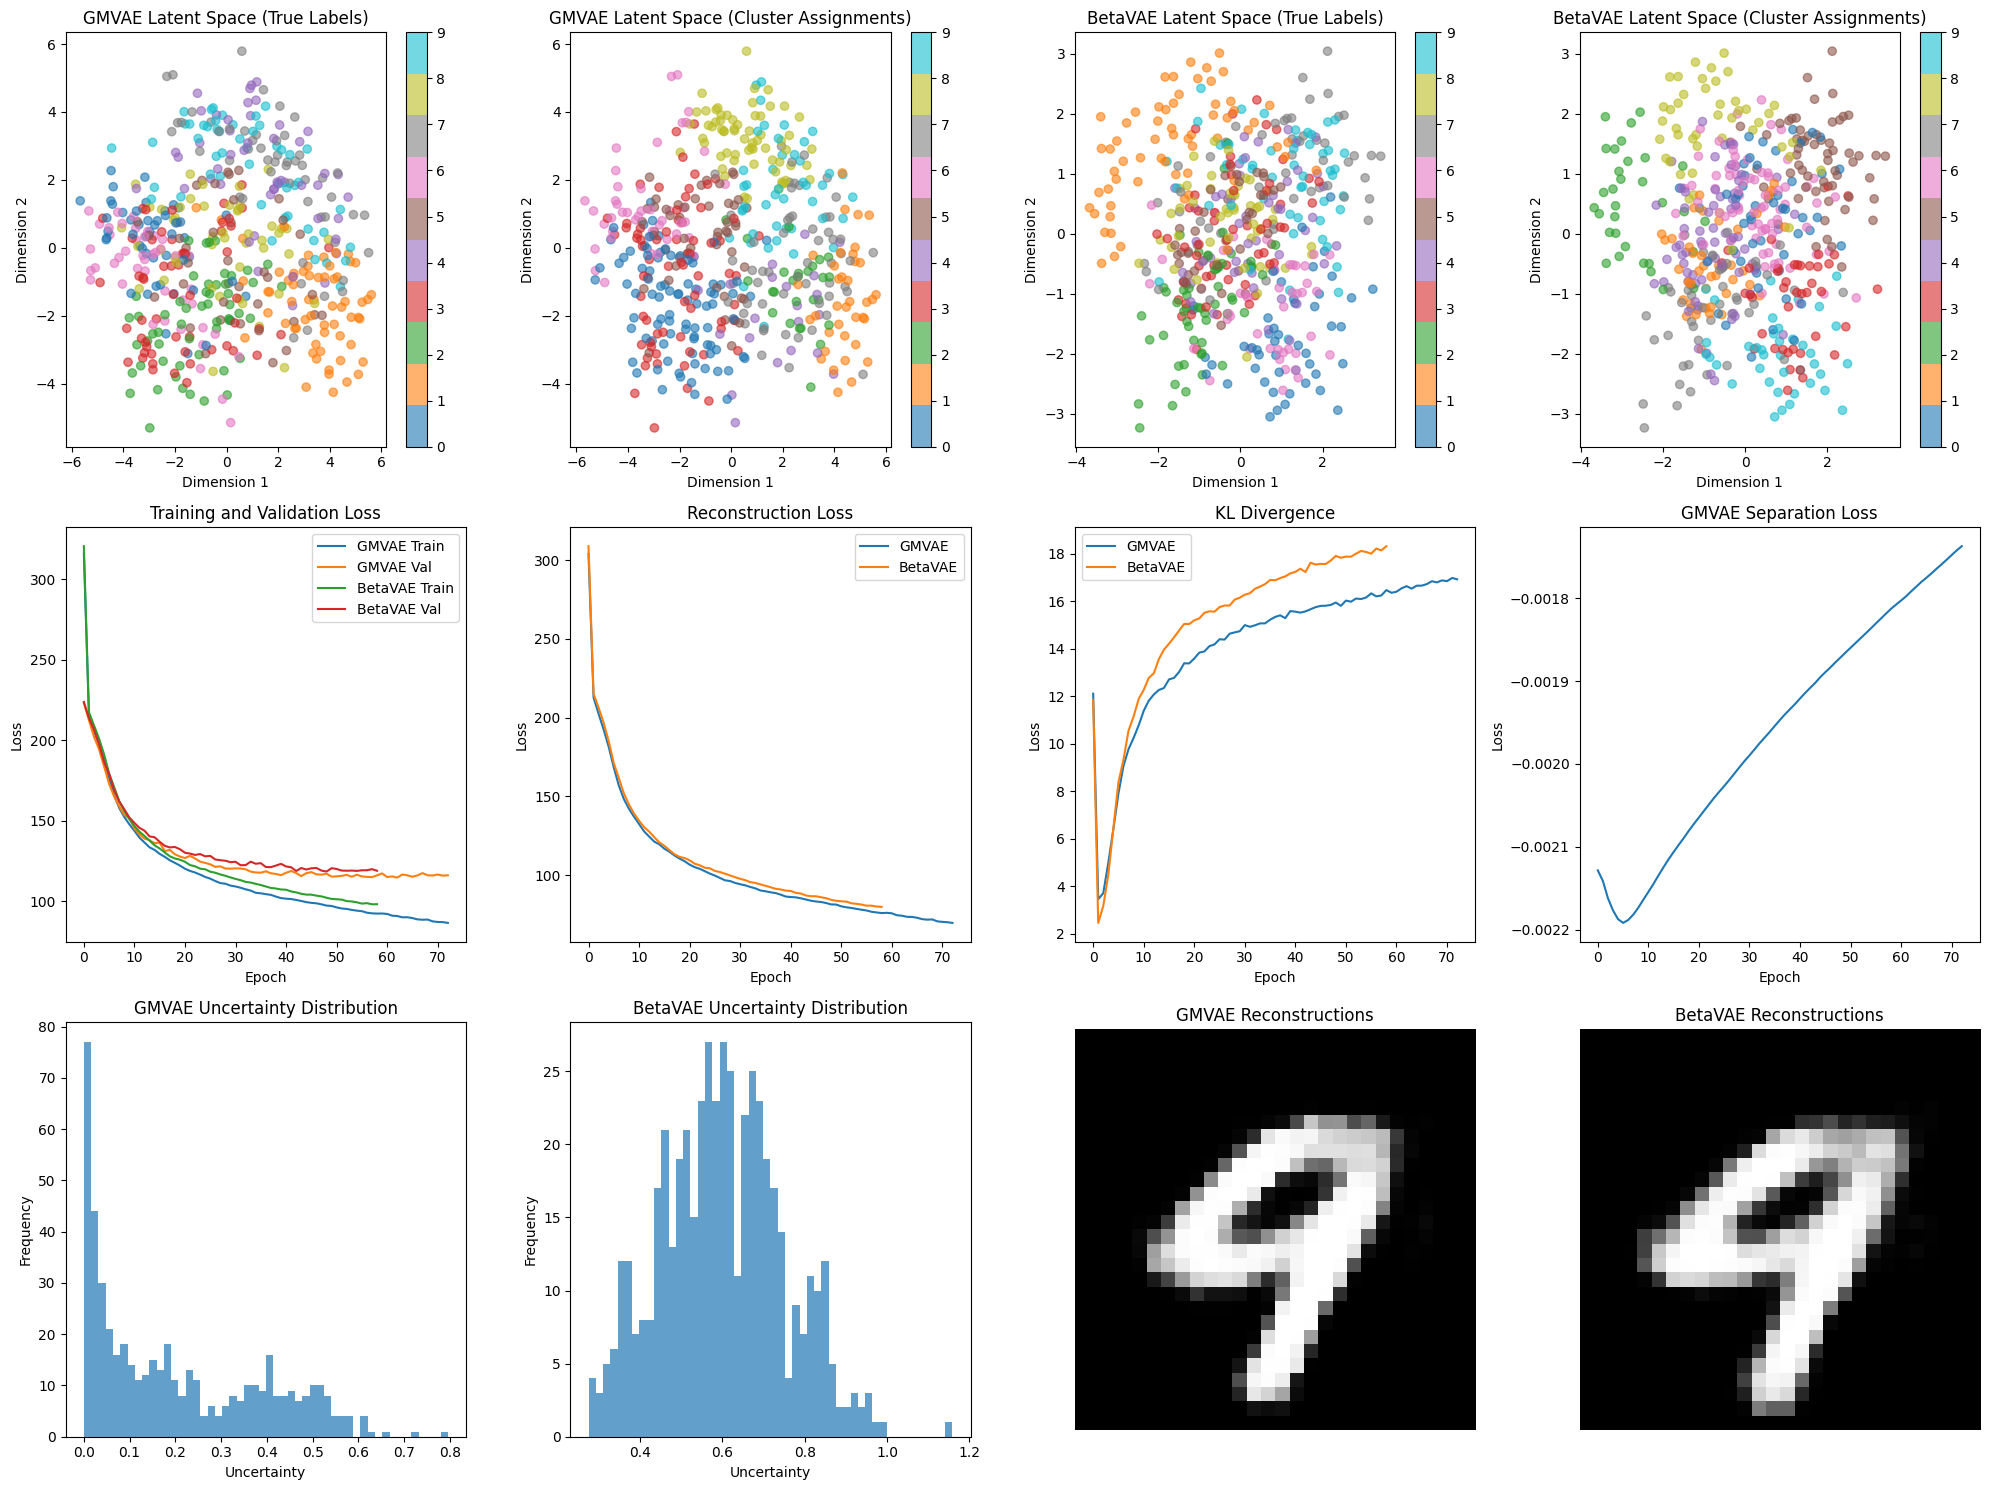

In [8]:
# Cell 8: Main execution function
# Main execution function
def main():
    # Initialize models
    gmvae_model = GMVAE().to(device)
    betavae_model = BetaVAE().to(device)

    # Optimizers
    gmvae_optimizer = optim.Adam(gmvae_model.parameters(), lr=learning_rate)
    betavae_optimizer = optim.Adam(betavae_model.parameters(), lr=learning_rate)

    # Train models with early stopping
    print("Training GMVAE...")
    gmvae_history = train_model(gmvae_model, train_loader, val_loader, gmvae_optimizer, "GMVAE")

    print("Training BetaVAE...")
    betavae_history = train_model(betavae_model, train_loader, val_loader, betavae_optimizer, "BetaVAE")

    # Evaluate models
    print("Evaluating GMVAE...")
    (gmvae_test_loss, gmvae_acc, gmvae_nmi, gmvae_ari, gmvae_silhouette,
     gmvae_z, gmvae_clusters, gmvae_labels, gmvae_recon, gmvae_uncertainty) = evaluate_model(gmvae_model, test_loader)

    print("Evaluating BetaVAE...")
    (betavae_test_loss, betavae_acc, betavae_nmi, betavae_ari, betavae_silhouette,
     betavae_z, betavae_clusters, betavae_labels, betavae_recon, betavae_uncertainty) = evaluate_model(betavae_model, test_loader)

    # Stability tests
    print("Running stability tests for GMVAE...")
    gmvae_stability = stability_test(GMVAE, train_loader, val_loader, test_loader)

    print("Running stability tests for BetaVAE...")
    betavae_stability = stability_test(BetaVAE, train_loader, val_loader, test_loader)

    # Print results
    print("\n=== Results ===")
    print("GMVAE Metrics:")
    print(f"Accuracy: {gmvae_acc:.4f}, NMI: {gmvae_nmi:.4f}, ARI: {gmvae_ari:.4f}, Silhouette: {gmvae_silhouette:.4f}")
    print(f"Stability - ACC: {gmvae_stability[0]:.4f}±{gmvae_stability[1]:.4f}, "
          f"NMI: {gmvae_stability[2]:.4f}±{gmvae_stability[3]:.4f}, "
          f"ARI: {gmvae_stability[4]:.4f}±{gmvae_stability[5]:.4f}, "
          f"Silhouette: {gmvae_stability[6]:.4f}±{gmvae_stability[7]:.4f}, "
          f"Time: {gmvae_stability[8]:.2f}±{gmvae_stability[9]:.2f}s")

    print("\nBetaVAE Metrics:")
    print(f"Accuracy: {betavae_acc:.4f}, NMI: {betavae_nmi:.4f}, ARI: {betavae_ari:.4f}, Silhouette: {betavae_silhouette:.4f}")
    print(f"Stability - ACC: {betavae_stability[0]:.4f}±{betavae_stability[1]:.4f}, "
          f"NMI: {betavae_stability[2]:.4f}±{betavae_stability[3]:.4f}, "
          f"ARI: {betavae_stability[4]:.4f}±{betavae_stability[5]:.4f}, "
          f"Silhouette: {betavae_stability[6]:.4f}±{betavae_stability[7]:.4f}, "
          f"Time: {betavae_stability[8]:.2f}±{betavae_stability[9]:.2f}s")

    # Visualization
    visualize_results(gmvae_model, betavae_model, gmvae_history, betavae_history,
                     gmvae_z, gmvae_labels, gmvae_clusters, gmvae_recon, gmvae_uncertainty,
                     betavae_z, betavae_labels, betavae_clusters, betavae_recon, betavae_uncertainty,
                     test_loader)

if __name__ == "__main__":
    main()